In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import scipy.ndimage as ndimage
import seaborn as sns
import os
import glob

In [2]:
path = '/climca/people/onennecke/model_output/bias_corrected_masked/winter_data/'
# path = '/climca/people/onennecke/model_output/not_bias_corrected/winter_data/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 18MB
Dimensions:        (ESM_run: 101, time: 1820)
Coordinates:
  * time           (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12...
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    run            (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
    ESM            (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
  * ESM_run        (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    winter_year    (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    day_of_winter  (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    winter_season  (time) <U8 58kB dask.array<chunksize=(1820,), meta=np.ndarray>
Data variables:
    temp           (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    demand         (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    sfcWind        (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    rsds           (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tas            (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tasmax         (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Netto          (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>

In [3]:
# Read csv file
df = pd.read_csv('/climca/people/onennecke/model_output/lr_correction/regression_coefficients.csv')
df

,variable,a,b
0,wind_onshore,1.998608,-51.476201
1,wind_offshore,1.565714,33.909284
2,solar,2.056006,62.904344
3,total_production,1.808454,111.069291


In [4]:
def apply_correction(df_coeffs, data_df, target_var, coeff_var, new_col=None):
    row = df_coeffs[df_coeffs['variable'] == coeff_var].iloc[0]
    a, b = row['a'], row['b']
    if not new_col:
        new_col = target_var + '_adj'
    data_df[new_col] = (data_df[target_var] - b) / a


In [5]:
ts_datasets

<xarray.Dataset> Size: 18MB
Dimensions:        (ESM_run: 101, time: 1820)
Coordinates:
  * time           (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12...
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    run            (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
    ESM            (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
  * ESM_run        (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    winter_year    (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    day_of_winter  (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    winter_season  (time) <U8 58kB dask.array<chunksize=(1820,), meta=np.ndarray>
Data variables:
    temp           (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    demand         (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    sfcWind        (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    rsds           (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tas            (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tasmax         (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Netto          (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>

In [6]:
apply_correction(df, ts_datasets, 'wind_off_prod', 'wind_offshore')
apply_correction(df, ts_datasets, 'wind_on_prod', 'wind_onshore')
apply_correction(df, ts_datasets, 'solar_prod', 'solar')
apply_correction(df, ts_datasets, 'total_prod', 'total_production')

ts_datasets['total_prod_adj_sum'] = ts_datasets['wind_off_prod_adj'] + ts_datasets['wind_on_prod_adj'] + ts_datasets['solar_prod_adj']
ts_datasets['Netto_adjusted'] = ts_datasets['total_prod_adj_sum'] - ts_datasets['demand']
ts_datasets['Residual_load_adj'] = ts_datasets['demand'] - ts_datasets['total_prod_adj_sum']

ts_datasets

<xarray.Dataset> Size: 28MB
Dimensions:             (ESM_run: 101, time: 1820)
Coordinates:
  * time                (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 20...
    crs                 int64 8B 4326
    gridtype            <U6 24B 'lonlat'
    country             float64 8B 9.0
    period              <U4 16B 'week'
    run                 (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
    ESM                 (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
  * ESM_run             (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-...
    winter_year         (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    day_of_winter       (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    winter_season       (time) <U8 58kB dask.array<chunksize=(1820,), meta=np.ndarray>
Data variables: (12/19)
    temp                (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    demand              (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    sfcWind             (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    rsds                (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tas                 (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    tasmax              (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    ...                  ...
    wind_on_prod_adj    (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    solar_prod_adj      (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    total_prod_adj      (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    total_prod_adj_sum  (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Netto_adjusted      (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Residual_load_adj   (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>

In [8]:
ts_datasets['solar_prod_adj'].values.min()

np.float64(-31.08588683551576)

In [9]:
# Save dataset
ts_datasets.to_netcdf('/climca/people/onennecke/model_output/bias_corrected_masked/winter_data/adjusted/final_model_output.nc')

### Plotting

In [10]:
# Plot timeseries with ts_datasets first year
ts_datasets_one = ts_datasets.isel(ESM_run=0)

# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
a = 91
b = 91 +181
# a = 365
# b = 365 * 2

# Extract time and variables for the chosen range
time = ts_datasets_one['time'][a:b]
demand = ts_datasets_one['demand'][a:b]
wind_off = ts_datasets_one['wind_off_prod'][a:b]
wind_on = ts_datasets_one['wind_on_prod'][a:b]
solar = ts_datasets_one['solar_prod'][a:b]
total_prod = ts_datasets_one['total_prod'][a:b]
Residual_load = ts_datasets_one['Residual_load'][a:b]
wind_off_adj = ts_datasets_one['wind_off_prod_adj'][a:b]
wind_on_adj = ts_datasets_one['wind_on_prod_adj'][a:b]
solar_adj = ts_datasets_one['solar_prod_adj'][a:b]
total_prod_adj = ts_datasets_one['total_prod_adj_sum'][a:b]
total_prod_adj_sum = ts_datasets_one['total_prod_adj_sum'][a:b]
Residual_load_adj = ts_datasets_one['Residual_load_adj'][a:b]

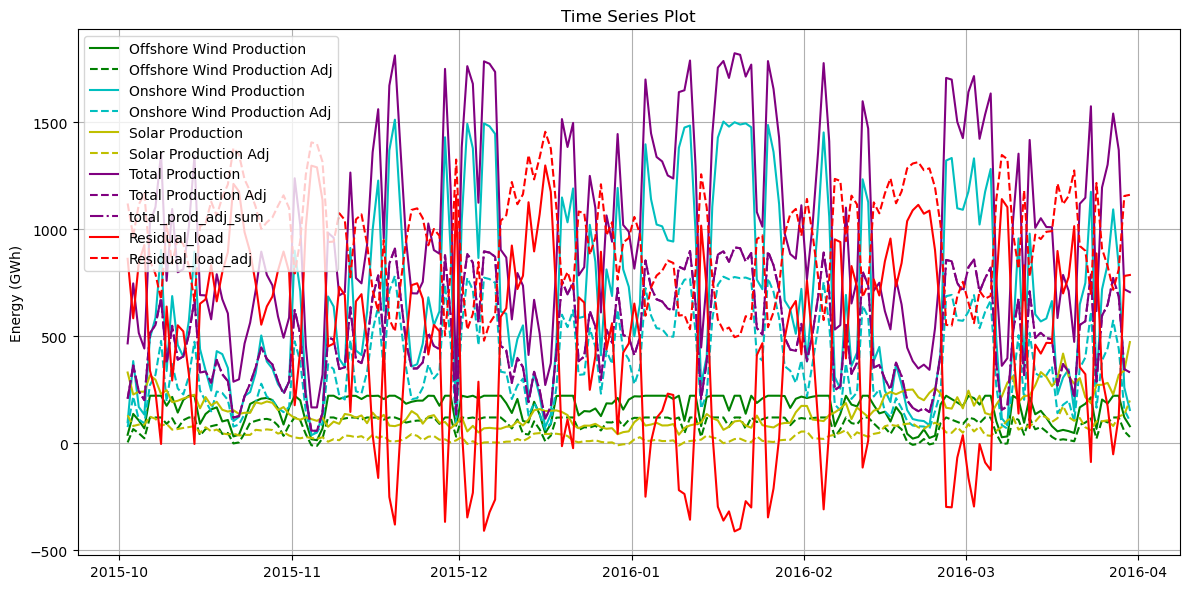

In [11]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
# ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_off_adj, label='Offshore Wind Production Adj', color='g', linestyle='--')

ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, wind_on_adj, label='Onshore Wind Production Adj', color='c', linestyle='--')

ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, solar_adj, label='Solar Production Adj', color='y', linestyle='--')

ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, total_prod_adj, label='Total Production Adj', color='purple', linestyle='--')
ax.plot(time, total_prod_adj_sum, label='total_prod_adj_sum', color='purple', linestyle='-.')

ax.plot(time, Residual_load, label='Residual_load', color='r')
ax.plot(time, Residual_load_adj, label='Residual_load_adj', color='r', linestyle='--')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

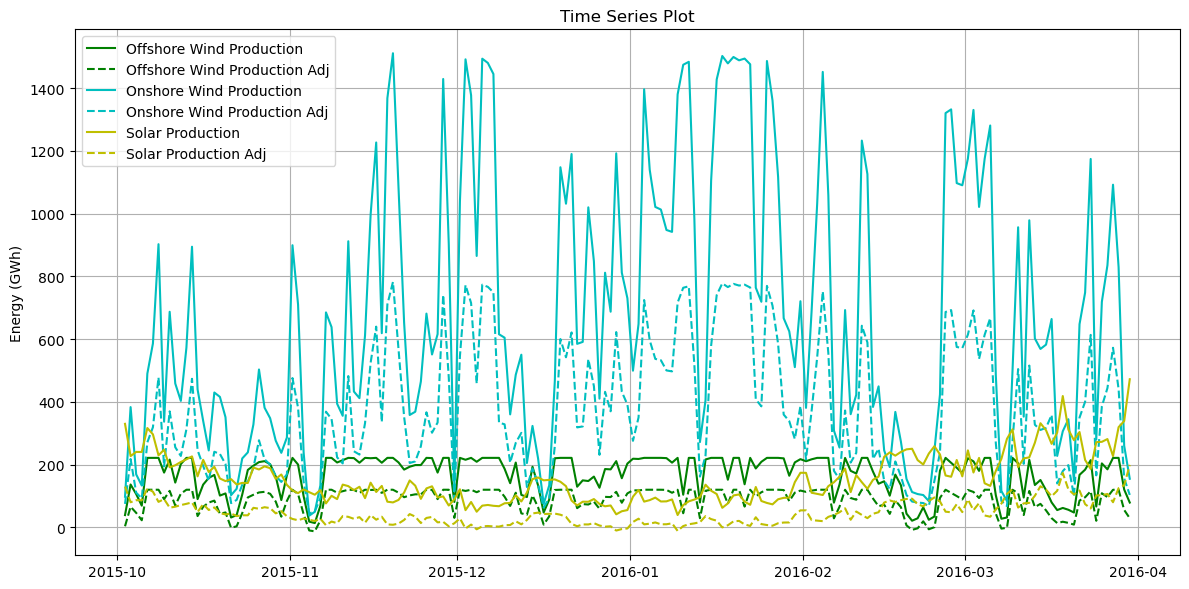

In [12]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
# ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_off_adj, label='Offshore Wind Production Adj', color='g', linestyle='--')

ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, wind_on_adj, label='Onshore Wind Production Adj', color='c', linestyle='--')

ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, solar_adj, label='Solar Production Adj', color='y', linestyle='--')

# ax.plot(time, total_prod, label='Total Production', color='purple')
# ax.plot(time, total_prod_adj, label='Total Production Adj', color='purple', linestyle='--')
# ax.plot(time, total_prod_adj_sum, label='total_prod_adj_sum', color='purple', linestyle='-.')

# ax.plot(time, Residual_load, label='Residual_load', color='r')
# ax.plot(time, Residual_load_adj, label='Residual_load_adj', color='r', linestyle='--')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

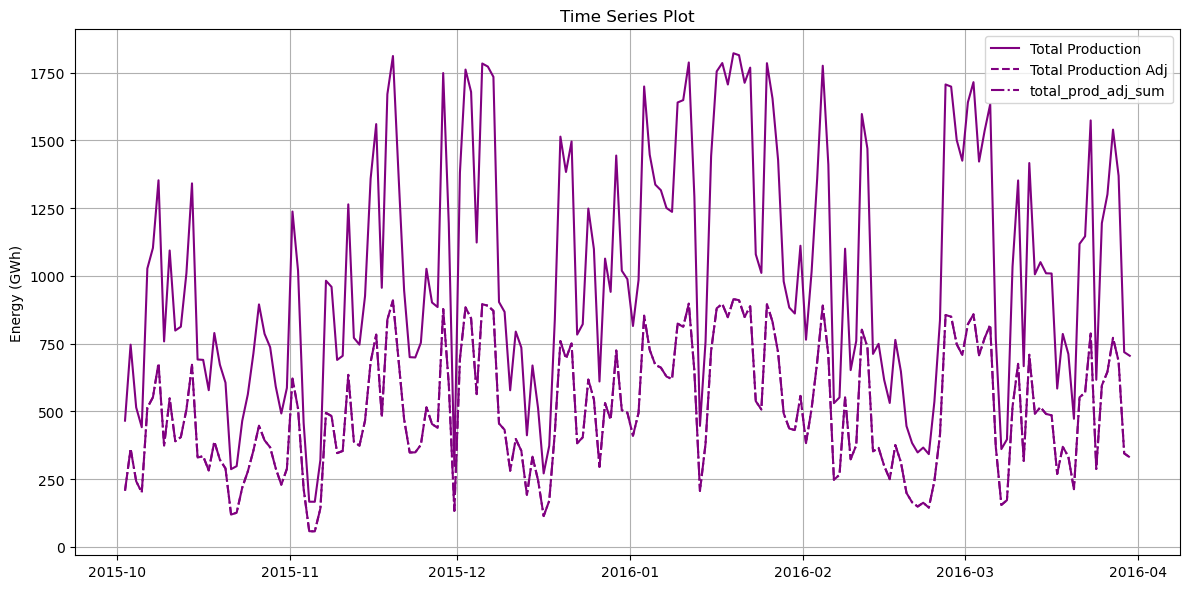

In [13]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
# ax.plot(time, demand, label='Demand', color='b')
# ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
# ax.plot(time, wind_off_adj, label='Offshore Wind Production Adj', color='g', linestyle='--')

# ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
# ax.plot(time, wind_on_adj, label='Onshore Wind Production Adj', color='c', linestyle='--')

# ax.plot(time, solar, label='Solar Production', color='y')
# ax.plot(time, solar_adj, label='Solar Production Adj', color='y', linestyle='--')

ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, total_prod_adj, label='Total Production Adj', color='purple', linestyle='--')
ax.plot(time, total_prod_adj_sum, label='total_prod_adj_sum', color='purple', linestyle='-.')

# ax.plot(time, Residual_load, label='Residual_load', color='r')
# ax.plot(time, Residual_load_adj, label='Residual_load_adj', color='r', linestyle='--')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

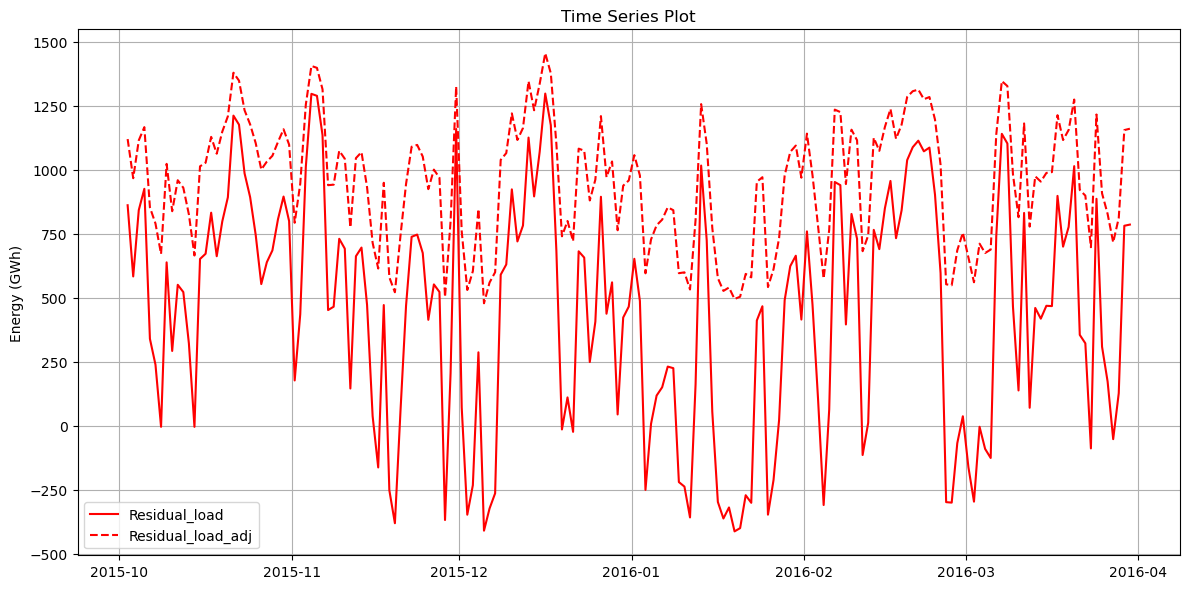

In [14]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
# ax.plot(time, demand, label='Demand', color='b')
# ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
# ax.plot(time, wind_off_adj, label='Offshore Wind Production Adj', color='g', linestyle='--')

# ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
# ax.plot(time, wind_on_adj, label='Onshore Wind Production Adj', color='c', linestyle='--')

# ax.plot(time, solar, label='Solar Production', color='y')
# ax.plot(time, solar_adj, label='Solar Production Adj', color='y', linestyle='--')

# ax.plot(time, total_prod, label='Total Production', color='purple')
# ax.plot(time, total_prod_adj, label='Total Production Adj', color='purple', linestyle='--')
# ax.plot(time, total_prod_adj_sum, label='total_prod_adj_sum', color='purple', linestyle='-.')

ax.plot(time, Residual_load, label='Residual_load', color='r')
ax.plot(time, Residual_load_adj, label='Residual_load_adj', color='r', linestyle='--')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()